# 06. Đánh giá và so sánh mô hình

Notebook này tương ứng **Bước 6: Đánh giá và so sánh mô hình**.

In [1]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents, DEFAULT_ROOT]:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Khong tim thay project root.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import preprocess_pipeline
from src.models.train import train_all_models
from src.models.evaluate import evaluate_models
from src.utils.config import load_project_config
from src.visualization.plots import plot_confusion_matrix, plot_roc_curve, plot_feature_importance

sns.set_theme(style='whitegrid')
config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
df = load_dataset(PROJECT_ROOT / config['paths']['raw_data'])
bundle = preprocess_pipeline(df, config)

# Ket noi voi Notebook 05: doc ket qua feature selection neu da chay truoc do.
metrics_dir = PROJECT_ROOT / 'models' / 'metrics'
feature_comparison_path = metrics_dir / 'feature_selection_comparison.csv'
selected_features_path = metrics_dir / 'selected_features.csv'

X_train_eval = bundle.X_train
X_test_eval = bundle.X_test
y_train_eval = bundle.y_train
y_test_eval = bundle.y_test
evaluation_feature_names = bundle.feature_names
feature_strategy = 'full_features'

if feature_comparison_path.exists() and selected_features_path.exists():
    feature_comparison_df = pd.read_csv(feature_comparison_path)
    selected_features = pd.read_csv(selected_features_path)['feature'].tolist()
    best_full_f1 = feature_comparison_df.query("feature_set == 'full_features'")['f1'].max()
    best_selected_f1 = feature_comparison_df.query("feature_set == 'selected_features'")['f1'].max()

    print('Ket qua tu Notebook 05:')
    print(f'- Best F1 full features: {best_full_f1:.4f}')
    print(f'- Best F1 selected features: {best_selected_f1:.4f}')

    if best_selected_f1 > best_full_f1 + 0.005:
        feature_strategy = 'selected_features'
        X_train_eval = bundle.X_train[selected_features]
        X_test_eval = bundle.X_test[selected_features]
        evaluation_feature_names = selected_features
        print('Quyet dinh: dung selected features cho buoc danh gia chinh thuc vi F1 tot hon ro rang.')
    else:
        print('Quyet dinh: giu full features cho buoc danh gia chinh thuc vi selected features khong cai thien ro rang.')

    display(feature_comparison_df.sort_values('f1', ascending=False))
else:
    print('Chua thay file ket qua Notebook 05, nen Notebook 06 se danh gia bang full features.')
    print('Neu muon noi mach day du, hay chay Notebook 05 truoc Notebook 06.')

trained_models, _ = train_all_models(X_train_eval, y_train_eval, config)
results_df, report_map = evaluate_models(trained_models, X_test_eval, y_test_eval)
print('Feature strategy used in Notebook 06:', feature_strategy)
results_df

Ket qua tu Notebook 05:
- Best F1 full features: 0.6034
- Best F1 selected features: 0.6165
Quyet dinh: dung selected features cho buoc danh gia chinh thuc vi F1 tot hon ro rang.


,model,feature_set,accuracy,precision,recall,f1,roc_auc
1,gradient_boosting,selected_features,0.765082,0.543967,0.711230,0.616454,0.833898
5,random_forest,selected_features,0.766501,0.549020,0.673797,0.605042,0.830005
3,logistic_regression,selected_features,0.740241,0.507246,0.748663,0.604752,0.822974
4,random_forest,full_features,0.765791,0.548035,0.671123,0.603365,0.828015
0,gradient_boosting,full_features,0.757275,0.533333,0.684492,0.599532,0.828262
2,logistic_regression,full_features,0.736693,0.502814,0.716578,0.590959,0.815531


Feature strategy used in Notebook 06: selected_features


,model,accuracy,precision,recall,f1,roc_auc
0,xgboost,0.772179,0.556503,0.697861,0.619217,0.833594
1,gradient_boosting,0.765082,0.543967,0.711230,0.616454,0.833898
2,notebook_voting_ensemble,0.753726,0.525813,0.735294,0.613155,0.833318
3,adaboost,0.744500,0.512590,0.762032,0.612903,0.829581
4,teacher_voting_ensemble,0.770759,0.555556,0.681818,0.612245,0.832917
5,random_forest,0.768630,0.552863,0.671123,0.606280,0.830237
6,logistic_regression,0.740241,0.507246,0.748663,0.604752,0.822974
7,lightgbm,0.770759,0.558352,0.652406,0.601726,0.823480
8,decision_tree,0.738822,0.506550,0.620321,0.557692,0.798750


## 1. So sánh các metric

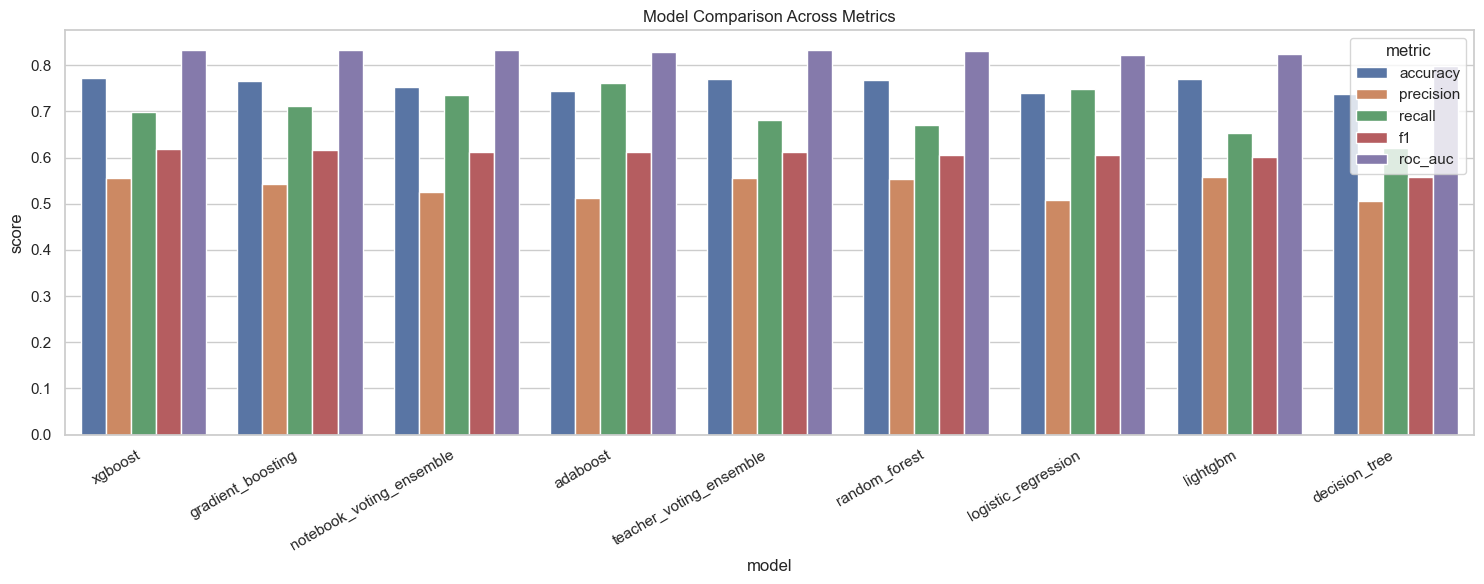

In [2]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
long_df = results_df.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='score')
plt.figure(figsize=(15, 6))
sns.barplot(data=long_df, x='model', y='score', hue='metric')
plt.title('Model Comparison Across Metrics')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 2. Đánh giá sâu model tốt nhất

In [3]:
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]
best_row = results_df.iloc[0].to_dict()

trained_models_dir = PROJECT_ROOT / config['paths']['trained_models_dir']
metrics_dir = PROJECT_ROOT / config['paths']['metrics_dir']
trained_models_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

best_model_path = trained_models_dir / config['artifacts']['best_model_file']
model_results_path = metrics_dir / config['artifacts']['metrics_file']
classification_report_path = metrics_dir / config['artifacts']['report_file']
best_model_summary_path = metrics_dir / 'best_model_summary.csv'

joblib.dump(best_model, best_model_path)
results_df.to_csv(model_results_path, index=False)
pd.DataFrame([{
    'best_model': best_model_name,
    'feature_strategy': feature_strategy,
    'accuracy': best_row['accuracy'],
    'precision': best_row['precision'],
    'recall': best_row['recall'],
    'f1': best_row['f1'],
    'roc_auc': best_row['roc_auc'],
    'model_path': str(best_model_path),
}]).to_csv(best_model_summary_path, index=False)

report_lines = []
for model_name, report in report_map.items():
    report_lines.append(f'=== {model_name} ===')
    report_lines.append(report)
    report_lines.append('')
classification_report_path.write_text('\n'.join(report_lines), encoding='utf-8')

print('Best model:', best_model_name)
print('Feature strategy:', feature_strategy)
print('Saved best model to:', best_model_path)
print('Saved model results to:', model_results_path)
print('Saved best model summary to:', best_model_summary_path)
print(report_map[best_model_name])

Best model: xgboost
Feature strategy: selected_features
Saved best model to: C:\vscode\hoctap\Customer-Churn-Analysis\models\trained_models\best_model.pkl
Saved model results to: C:\vscode\hoctap\Customer-Churn-Analysis\models\metrics\model_results.csv
Saved best model summary to: C:\vscode\hoctap\Customer-Churn-Analysis\models\metrics\best_model_summary.csv
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



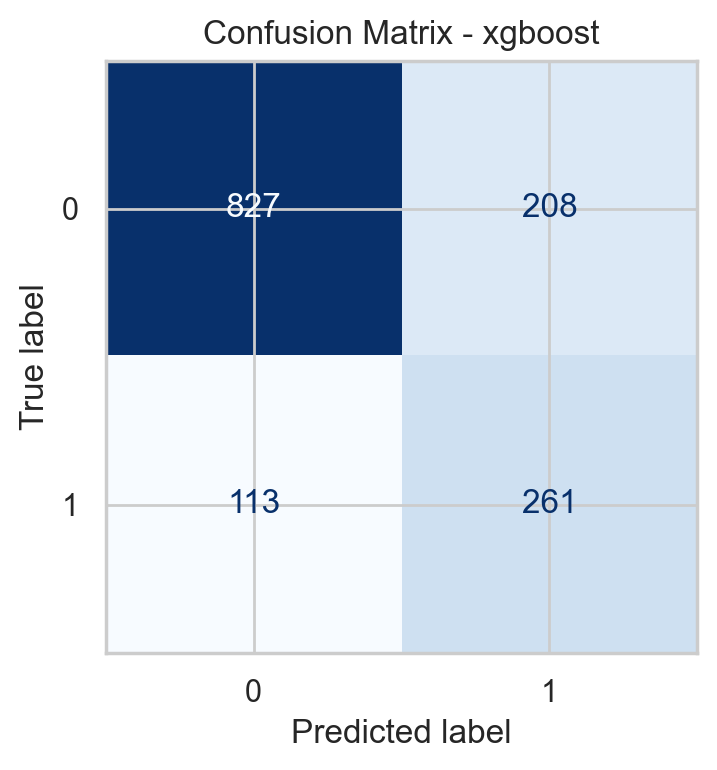

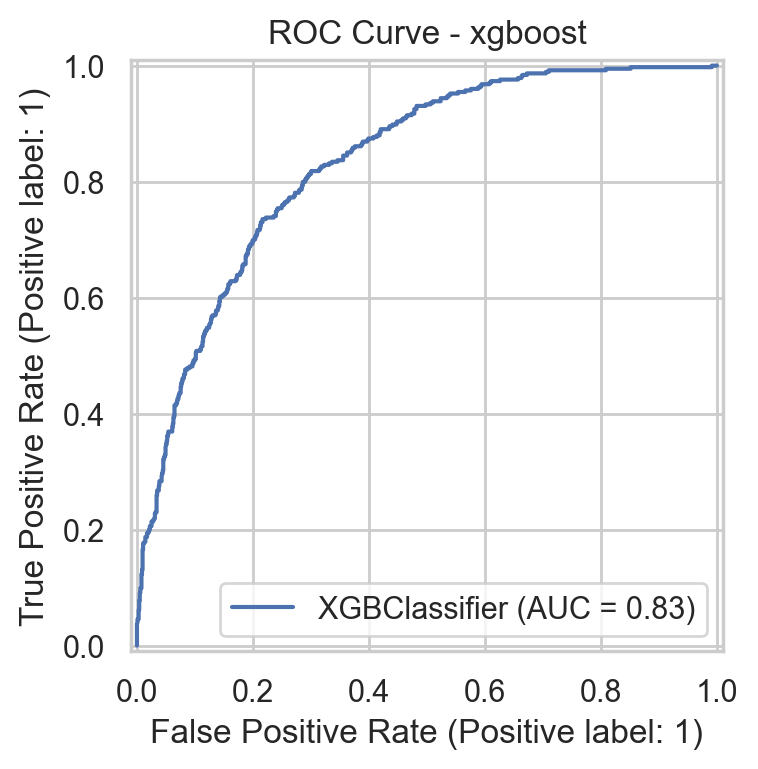

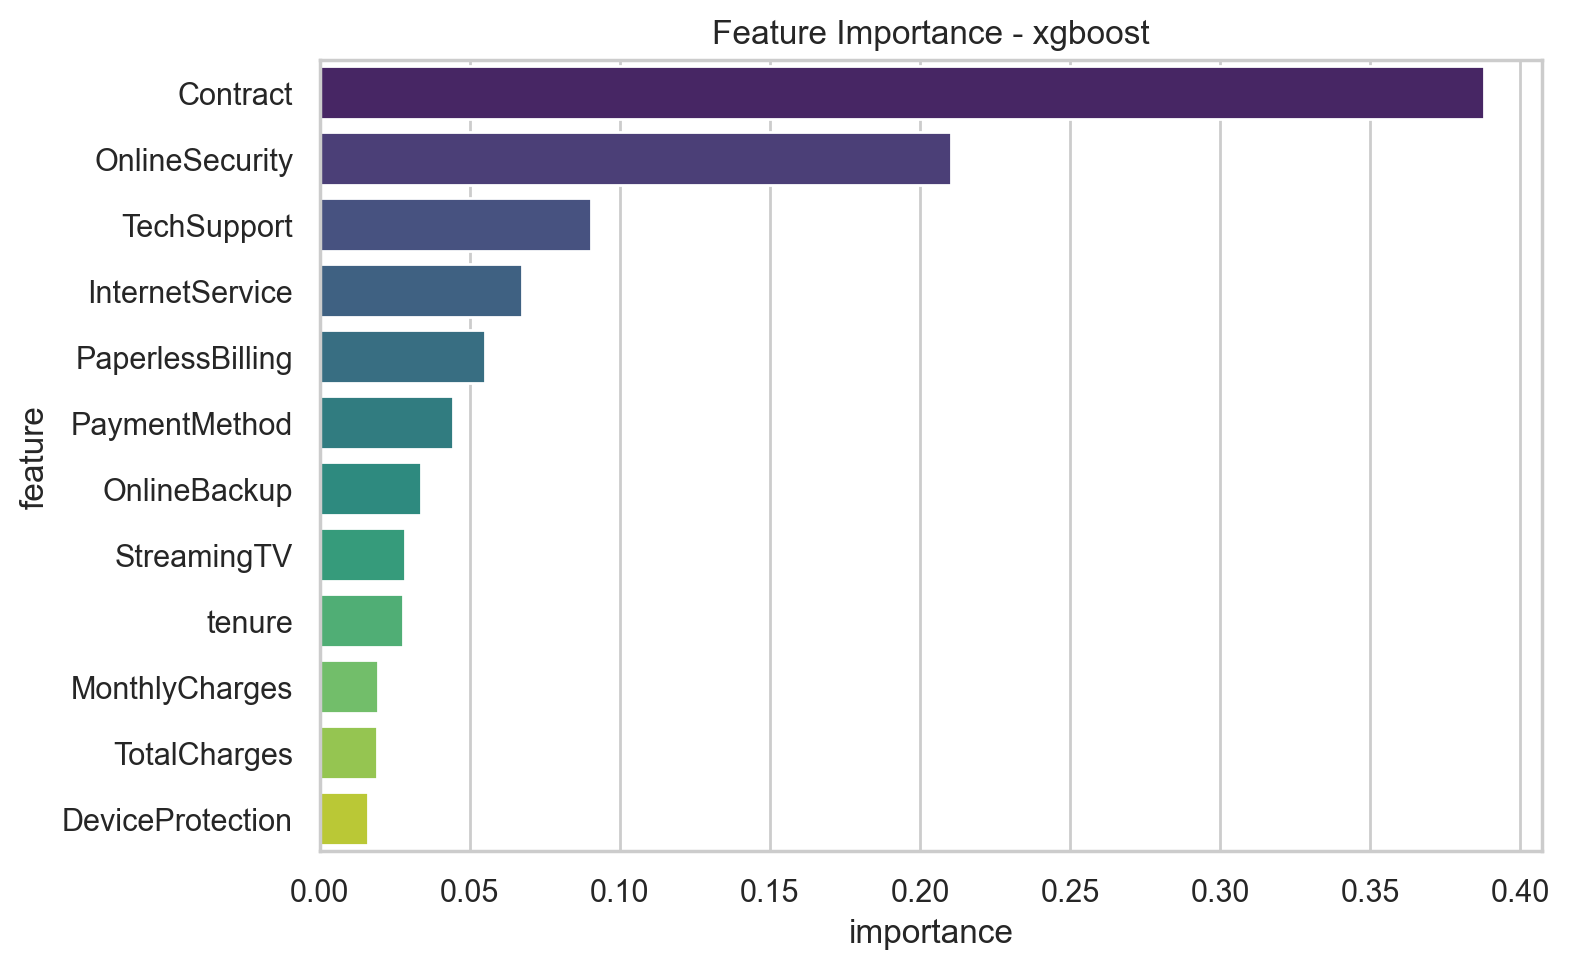

In [4]:
figures_dir = PROJECT_ROOT / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
y_pred = best_model.predict(X_test_eval)

cm_path = figures_dir / f'{best_model_name}_confusion_matrix_step06.png'
roc_path = figures_dir / f'{best_model_name}_roc_curve_step06.png'
fi_path = figures_dir / f'{best_model_name}_feature_importance_step06.png'

plot_confusion_matrix(y_test_eval, y_pred, cm_path, title=f'Confusion Matrix - {best_model_name}')
plot_roc_curve(best_model, X_test_eval, y_test_eval, roc_path, title=f'ROC Curve - {best_model_name}')
plot_feature_importance(best_model, evaluation_feature_names, fi_path, title=f'Feature Importance - {best_model_name}')

display(Image(filename=str(cm_path)))
display(Image(filename=str(roc_path)))
if fi_path.exists():
    display(Image(filename=str(fi_path)))

## Kết luận bước 6

- Không chỉ nhìn accuracy; cần xem thêm precision, recall, f1 và roc_auc.
- Với churn, `f1` và `recall` rất quan trọng vì cần phát hiện khách hàng có nguy cơ rời bỏ.
- Notebook 06 đã đọc kết quả từ Notebook 05 nếu có file `feature_selection_comparison.csv` và `selected_features.csv`.
- Nếu selected features tốt hơn rõ ràng, Notebook 06 dùng selected features để đánh giá chính thức.
- Nếu selected features không cải thiện rõ, Notebook 06 giữ full features để tránh mất thông tin.
- Notebook 06 lưu lại best model vào `models/trained_models/best_model.pkl`.
- Notebook 06 cũng lưu `model_results.csv`, `classification_report.txt` và `best_model_summary.csv` để Notebook 07 đọc lại.
- Confusion matrix, ROC curve và feature importance giúp giải thích kết quả sâu hơn.